In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style
sns.set_theme(style="whitegrid")

# 1. Load each table into its own distinct variable
df_consumption = pd.read_csv('consumption.csv')
df_deliveries = pd.read_csv('deliveries.csv')
df_facilities = pd.read_csv('facilities.csv')
df_inventory = pd.read_csv('inventory_levels.csv')
df_stockouts = pd.read_csv('stockout_events.csv')

# 2. Convert date columns back to datetime objects
df_consumption['date'] = pd.to_datetime(df_consumption['date'])
df_deliveries['expected_delivery_date'] = pd.to_datetime(df_deliveries['expected_delivery_date'])
df_deliveries['actual_delivery_date'] = pd.to_datetime(df_deliveries['actual_delivery_date'])
df_inventory['audit_date'] = pd.to_datetime(df_inventory['audit_date'])
df_stockouts['stockout_date'] = pd.to_datetime(df_stockouts['stockout_date'])

print("All datasets loaded successfully!")

All datasets loaded successfully!


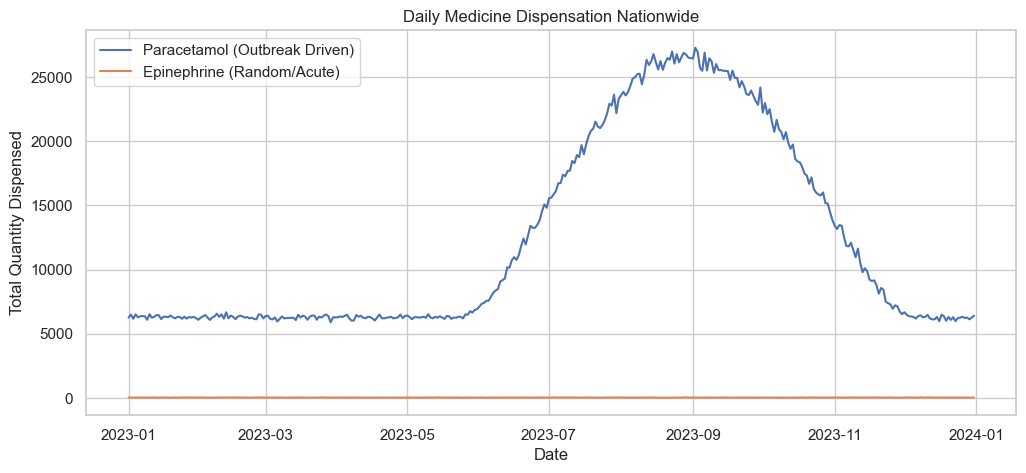

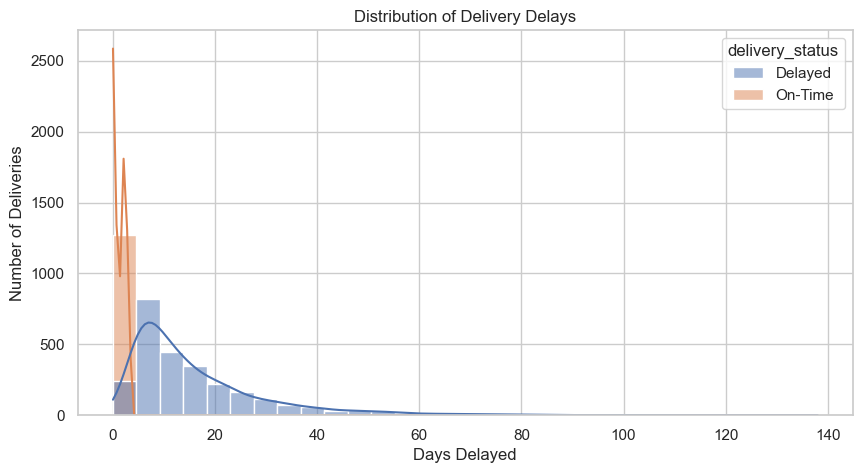

In [3]:
# ==========================================
# Task A: The Outbreak Curve
# ==========================================
plt.figure(figsize=(12, 5))

# Group daily consumption by medicine type
daily_meds = df_consumption.groupby(['date', 'medicine_code'])['quantity_dispensed'].sum().reset_index()

# Plot Paracetamol vs Epinephrine
sns.lineplot(data=daily_meds[daily_meds['medicine_code'] == 'PARACETAMOL'], x='date', y='quantity_dispensed', label='Paracetamol (Outbreak Driven)')
sns.lineplot(data=daily_meds[daily_meds['medicine_code'] == 'EPINEPHRINE'], x='date', y='quantity_dispensed', label='Epinephrine (Random/Acute)')

plt.title("Daily Medicine Dispensation Nationwide")
plt.ylabel("Total Quantity Dispensed")
plt.xlabel("Date")
plt.legend()
plt.show()

# ==========================================
# Task B: The Supply Chain Messiness
# ==========================================
plt.figure(figsize=(10, 5))

# Plot the distribution of delivery delays
sns.histplot(data=df_deliveries, x='transit_delay_days', hue='delivery_status', bins=30, kde=True)

plt.title("Distribution of Delivery Delays")
plt.xlabel("Days Delayed")
plt.ylabel("Number of Deliveries")
plt.show()

Preparing data for Machine Learning...
Total Audit Records: 3600
Stockouts found in next 30 days: 452

--- Model Evaluation ---
              precision    recall  f1-score   support

           0       0.99      0.92      0.96       630
           1       0.63      0.97      0.76        90

    accuracy                           0.93       720
   macro avg       0.81      0.94      0.86       720
weighted avg       0.95      0.93      0.93       720



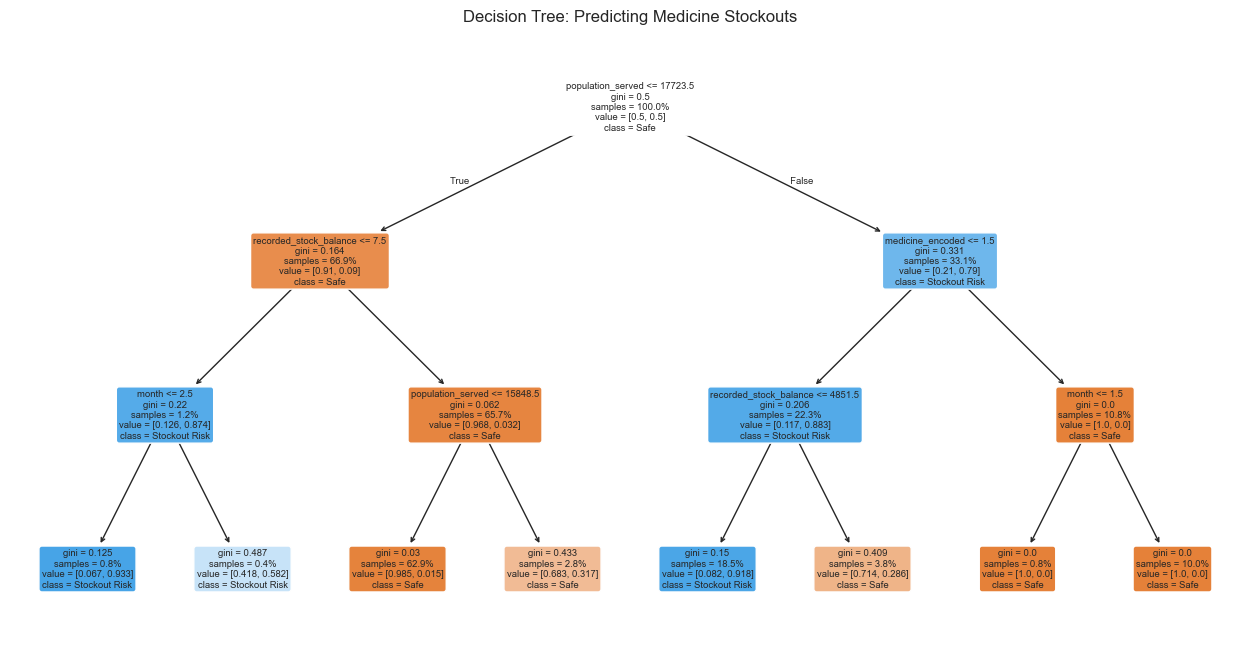

In [5]:
# ==========================================
# Task C: Machine Learning (Predicting Stockouts)
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import numpy as np

print("Preparing data for Machine Learning...")

# 1. Feature Engineering (The Analytical Base Table)
# Start with our monthly audits
df_ml = df_inventory.copy()

# Add facility features
df_ml = df_ml.merge(df_facilities[['facility_id', 'region_type', 'population_served']], on='facility_id', how='left')

# Add time features
df_ml['month'] = df_ml['audit_date'].dt.month

# 2. Create the Target Variable (Y): "Did a stockout happen in the next 30 days?"
# We will use a fast custom function to check the stockout_events table
def check_future_stockout(row):
    # Look for stockouts for this facility and medicine
    future_events = df_stockouts[
        (df_stockouts['facility_id'] == row['facility_id']) & 
        (df_stockouts['medicine_code'] == row['medicine_code']) &
        (df_stockouts['stockout_date'] > row['audit_date']) & 
        (df_stockouts['stockout_date'] <= row['audit_date'] + pd.Timedelta(days=30))
    ]
    return 1 if len(future_events) > 0 else 0

# Apply the function to create our target label (1 = Stockout, 0 = Safe)
df_ml['target_stockout_next_30_days'] = df_ml.apply(check_future_stockout, axis=1)

print(f"Total Audit Records: {len(df_ml)}")
print(f"Stockouts found in next 30 days: {df_ml['target_stockout_next_30_days'].sum()}")

# 3. Prepare for Scikit-Learn (Encode categorical variables)
le_region = LabelEncoder()
df_ml['region_encoded'] = le_region.fit_transform(df_ml['region_type'])

le_med = LabelEncoder()
df_ml['medicine_encoded'] = le_med.fit_transform(df_ml['medicine_code'])

# Select features (X) and target (y)
features = ['recorded_stock_balance', 'population_served', 'month', 'region_encoded', 'medicine_encoded']
X = df_ml[features]
y = df_ml['target_stockout_next_30_days']

# Train/Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Train the Decision Tree
# We restrict depth to 3 so we can easily plot and explain it
clf = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

# 5. Evaluate the Model
y_pred = clf.predict(X_test)
print("\n--- Model Evaluation ---")
print(classification_report(y_test, y_pred))

# 6. Visualize the Tree's Decision Logic
plt.figure(figsize=(16, 8))
plot_tree(clf, feature_names=features, class_names=['Safe', 'Stockout Risk'], filled=True, rounded=True, proportion=True)
plt.title("Decision Tree: Predicting Medicine Stockouts")
plt.show()